# Notebook 01- Previsão de Custo

**Replicação de:** Wong et al. (2023). *Using Spark Machine Learning Models to Perform Predictive Analysis on Flight Ticket Pricing Data*. arXiv:2310.07787. https://arxiv.org/abs/2310.07787  
**Dataset:** Flight Prices- Expedia via Kaggle. https://www.kaggle.com/datasets/dilwong/flightprices  
**Target:** `baseFare` (preço base do bilhete em USD)  
**Modelos:** Random Forest, Gradient Boost Tree, Decision Tree, Factorization Machines  


## Resultados de referência do paper (Full Dataset - Train Validation)

| Modelo | R² | RMSE (USD) | Tempo de treino do modelo |
|---|---|---|---|
| Random Forest | 0.728 | 79.92 | 1h 30min |
| Gradient Boost Tree | 0.706 | 83.17 | 53min |
| Decision Tree | 0.640 | 92.04 | 47min |
| Factorization Machines | 0.460 | 111.02 | 3h |


**Nota metodológica:** O paper usou Spark num cluster de 5 nós (8 CPUs, 481GB storage, Hadoop 3.2.1).  
Esta replicação usa pandas + sklearn.
Os 4 modelos são os mesmos do paper. As Factorization Machines são implementadas via `PolynomialFeatures(degree=2) + Ridge` - proxy sklearn que captura as interações entre pares de features que constituem o núcleo das FM. O `fastFM` não suporta Windows.

## 0. Instalação de dependências e imports

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import json
import joblib
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Imports OK')

Imports OK


## 1. Carregamento do dataset

O dataset original tem ~200M registos (31GB). O paper filtra para voos **non-stop** → ~20M registos (4.86GB), e depois usa uma **amostra de 10%** (~100k registos) para hyperparameter tuning e comparação final.

Aqui carregamos em chunks para não ter os 31GB em memória de uma vez.

**Fluxo de carregamento:**
- **1ª execução:** lê chunks do CSV (30-60 min), guarda amostra em `df_nonstop_sample.parquet`
- **Execuções seguintes:** carrega directamente do parquet (segundos) para poupar tempo

In [11]:
# Ajusta este path para onde tens o ficheiro descarregado
DATA_PATH = 'itineraries.csv'

# Ver o header primeiro
df_header = pd.read_csv(DATA_PATH, nrows=3)
print('Colunas originais:')
for col in df_header.columns:
    print(f'  {col}: {df_header[col].dtype}- ex: {df_header[col].iloc[0]}')

Colunas originais:
  legId: object- ex: 9ca0e81111c683bec1012473feefd28f
  searchDate: object- ex: 2022-04-16
  flightDate: object- ex: 2022-04-17
  startingAirport: object- ex: ATL
  destinationAirport: object- ex: BOS
  fareBasisCode: object- ex: LA0NX0MC
  travelDuration: object- ex: PT2H29M
  elapsedDays: int64- ex: 0
  isBasicEconomy: bool- ex: False
  isRefundable: bool- ex: False
  isNonStop: bool- ex: True
  baseFare: float64- ex: 217.67
  totalFare: float64- ex: 248.6
  seatsRemaining: int64- ex: 9
  totalTravelDistance: int64- ex: 947
  segmentsDepartureTimeEpochSeconds: int64- ex: 1650214620
  segmentsDepartureTimeRaw: object- ex: 2022-04-17T12:57:00.000-04:00
  segmentsArrivalTimeEpochSeconds: int64- ex: 1650223560
  segmentsArrivalTimeRaw: object- ex: 2022-04-17T15:26:00.000-04:00
  segmentsArrivalAirportCode: object- ex: BOS
  segmentsDepartureAirportCode: object- ex: ATL
  segmentsAirlineName: object- ex: Delta
  segmentsAirlineCode: object- ex: DL
  segmentsEquipmentDes

In [12]:
'''
# Carregar em chunks filtrando non-stop
print('A carregar e filtrar dataset em chunks...')

chunks = []
chunk_size = 500_000
total_rows = 0
nonstop_rows = 0

for chunk in pd.read_csv(DATA_PATH, chunksize=chunk_size, low_memory=False):
    total_rows += len(chunk)

    # Filtro non-stop- o paper filtra explicitamente para non-stop flights
    if 'isNonStop' in chunk.columns:
        mask = chunk['isNonStop'] == True
    elif 'segmentsStops' in chunk.columns:
        mask = chunk['segmentsStops'].astype(str) == '0'
    else:
        mask = pd.Series([True] * len(chunk))

    chunk_ns = chunk[mask]
    nonstop_rows += len(chunk_ns)
    chunks.append(chunk_ns)

    if total_rows % 10_000_000 == 0:
        print(f'  {total_rows/1e6:.0f}M processados- non-stop acumulado: {nonstop_rows/1e6:.1f}M')

df_nonstop = pd.concat(chunks, ignore_index=True)
del chunks

print(f'\nTotal original: {total_rows:,}')
print(f'Após filtro non-stop: {len(df_nonstop):,} ({len(df_nonstop)/total_rows*100:.1f}%)')
print(f'(Paper reporta ~20M non-stop de ~200M total)')
'''

"\n# Carregar em chunks filtrando non-stop\nprint('A carregar e filtrar dataset em chunks...')\n\nchunks = []\nchunk_size = 500_000\ntotal_rows = 0\nnonstop_rows = 0\n\nfor chunk in pd.read_csv(DATA_PATH, chunksize=chunk_size, low_memory=False):\n    total_rows += len(chunk)\n\n    # Filtro non-stop- o paper filtra explicitamente para non-stop flights\n    if 'isNonStop' in chunk.columns:\n        mask = chunk['isNonStop'] == True\n    elif 'segmentsStops' in chunk.columns:\n        mask = chunk['segmentsStops'].astype(str) == '0'\n    else:\n        mask = pd.Series([True] * len(chunk))\n\n    chunk_ns = chunk[mask]\n    nonstop_rows += len(chunk_ns)\n    chunks.append(chunk_ns)\n\n    if total_rows % 10_000_000 == 0:\n        print(f'  {total_rows/1e6:.0f}M processados- non-stop acumulado: {nonstop_rows/1e6:.1f}M')\n\ndf_nonstop = pd.concat(chunks, ignore_index=True)\ndel chunks\n\nprint(f'\nTotal original: {total_rows:,}')\nprint(f'Após filtro non-stop: {len(df_nonstop):,} ({len(df_

In [13]:
'''
# Amostra de 10% - exatamente como o paper
SAMPLE_FRAC = 0.10
df = df_nonstop.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).reset_index(drop=True)
del df_nonstop

print(f'Amostra ({SAMPLE_FRAC*100:.0f}%): {len(df):,} registos')
print(f'(Paper usou ~100k registos como sample)')
df.head(3)
'''

"\n# Amostra de 10% - exatamente como o paper\nSAMPLE_FRAC = 0.10\ndf = df_nonstop.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).reset_index(drop=True)\ndel df_nonstop\n\nprint(f'Amostra ({SAMPLE_FRAC*100:.0f}%): {len(df):,} registos')\nprint(f'(Paper usou ~100k registos como sample)')\ndf.head(3)\n"

In [ ]:
# SAVE / LOAD - evita re-correr os chunks em cada sessão
import os

PARQUET_PATH = 'df_nonstop_sample.parquet'

if os.path.exists(PARQUET_PATH):
    # MODO RÁPIDO: carrega do parquet (segundos)
    print(f'A carregar amostra do parquet: {PARQUET_PATH}')
    df = pd.read_parquet(PARQUET_PATH)
    print(f'Carregado: {len(df):,} registos')
else:
    # PRIMEIRA VEZ: df já está em memória vindo das células anteriores
    # Guarda o parquet para sessões futuras
    print('A guardar amostra em parquet para sessões futuras...')
    df.to_parquet(PARQUET_PATH, index=False)
    print(f'Guardado: {PARQUET_PATH} ({os.path.getsize(PARQUET_PATH)/1e6:.1f} MB)')
    print(f'Da próxima vez este ficheiro é carregado diretamente (sem chunks).')


A carregar amostra do parquet: df_nonstop_sample.parquet


Carregado: 2,206,689 registos


## 2. Limpeza e feature engineering



O paper usa 14 features + 1 label (`baseFare`). As features identificadas por feature importance (Fig. 3 do paper) são, por ordem de importância:

`startingAirport` > `segmentsDurationInSeconds` > `destinationAirport` > `seatsRemaining` > `segmentsArrivalTimeEpochSeconds` > `segmentsCabinCode` > `segmentsEquipmentDescription` > `segmentsAirlineCode` > `totalTravelDistance` > `searchMonth` > `segmentsDepartureTimeEpochSeconds` > `isBasicEconomy` > `flightMonth` > `searchDay`

In [ ]:
# Remover linhas sem target
print(f'Antes limpeza: {len(df):,}')
df = df.dropna(subset=['baseFare'])

# Remover preços não aceitáveis (< 20 USD ou > 5000 USD)
df = df[(df['baseFare'] >= 20) & (df['baseFare'] <= 5000)]
print(f'Após limpeza de preços: {len(df):,}')

# Extrair features temporais de flightDate e searchDate
for date_col, prefix in [('flightDate', 'flight'), ('searchDate', 'search')]:
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        df[f'{prefix}Month'] = df[date_col].dt.month
        df[f'{prefix}Day']   = df[date_col].dt.day
        df[f'{prefix}Year']  = df[date_col].dt.year
        df[f'{prefix}DayOfWeek'] = df[date_col].dt.dayofweek

# Dias de antecedência à compra - feature relevante não explicitada no paper, mas implícita em searchDate vs flightDate
if 'flightDate' in df.columns and 'searchDate' in df.columns:
    df['daysToFlight'] = (df['flightDate'] - df['searchDate']).dt.days.clip(lower=0)

print('Features temporais extraídas.')

Antes limpeza: 2,206,689
Após limpeza de preços: 2,183,203
Features temporais extraídas.


In [ ]:
# Definir features exatamente como o paper (Fig. 2)
# 14 features + 1 label (baseFare)

# Features do paper:
# searchDate, flightDate → extraídas em componentes temporais na célula anterior
# startingAirport, destinationAirport → categóricas
# isBasicEconomy, isRefundable → binárias
# seatsRemaining, totalTravelDistance → numéricas
# segmentsDepartureTimeEpochSeconds, segmentsArrivalTimeEpochSeconds → numéricas
# segmentsAirlineCode, segmentsEquipmentDescription, segmentsCabinCode → categóricas
# segmentsDurationInSeconds → numérica

# NOTA sobre searchDate e flightDate: O paper usa as datas como features. Como são strings não usáveis 
# diretamente, extraímos os componentes numéricos equivalentes: searchMonth, searchDay,
# flightMonth, flightDay - que representam a mesma informação temporal.

# NOTA sobre isRefundable: O paper inclui esta feature. No nosso dataset é constante (todos False),
# por isso não tem poder preditivo mas é mantida para fidelidade ao paper.

CANDIDATE_CAT = [
    'startingAirport',
    'destinationAirport',
    'segmentsAirlineCode',
    'segmentsCabinCode',
    'segmentsEquipmentDescription',
]
CANDIDATE_NUM = [
    # Representação numérica de searchDate e flightDate (como no paper)
    'searchMonth', 'searchDay',
    'flightMonth', 'flightDay',
    # Restantes numéricas do paper
    'seatsRemaining',
    'totalTravelDistance',
    'segmentsDurationInSeconds',
    'segmentsDepartureTimeEpochSeconds',
    'segmentsArrivalTimeEpochSeconds',
    # flightDayOfWeek e daysToFlight REMOVIDOS: não estão no paper
]
CANDIDATE_BIN = [
    'isBasicEconomy',
    'isRefundable',  # paper inclui esta feature; constante no dataset mas mantida por fidelidade
    # isNonStop REMOVIDO: constante
]
TARGET = 'baseFare'

# Filtrar só as que existem no dataframe
CAT = [f for f in CANDIDATE_CAT if f in df.columns]
NUM = [f for f in CANDIDATE_NUM if f in df.columns]
BIN = [f for f in CANDIDATE_BIN if f in df.columns]
ALL_FEATURES = CAT + NUM + BIN

print(f'Features categóricas ({len(CAT)}): {CAT}')
print(f'Features numéricas   ({len(NUM)}): {NUM}')
print(f'Features binárias    ({len(BIN)}): {BIN}')
print(f'Total features: {len(ALL_FEATURES)} (paper usa 14)')
print()
print('Mapeamento face ao paper:')
print('  searchDate  → searchMonth + searchDay')
print('  flightDate  → flightMonth + flightDay')
print('  isRefundable → mantida (constante no dataset - todos False)')
print('  isNonStop    → removida (constante - todos True após filtro non-stop)')
print('  flightDayOfWeek, daysToFlight → removidas (não estão no paper)')


Features categóricas (5): ['startingAirport', 'destinationAirport', 'segmentsAirlineCode', 'segmentsCabinCode', 'segmentsEquipmentDescription']
Features numéricas   (9): ['searchMonth', 'searchDay', 'flightMonth', 'flightDay', 'seatsRemaining', 'totalTravelDistance', 'segmentsDurationInSeconds', 'segmentsDepartureTimeEpochSeconds', 'segmentsArrivalTimeEpochSeconds']
Features binárias    (2): ['isBasicEconomy', 'isRefundable']
Total features: 16 (paper usa 14)

Mapeamento face ao paper:
  searchDate  → searchMonth + searchDay
  flightDate  → flightMonth + flightDay
  isRefundable → mantida (constante no dataset - todos False)
  isNonStop    → removida (constante - todos True após filtro non-stop)
  flightDayOfWeek, daysToFlight → removidas (não estão no paper)


In [17]:
# Preparar df_model
df_model = df[ALL_FEATURES + [TARGET]].copy().dropna()
print(f'Dataset final para modelação: {df_model.shape}')

# Label encoding para categóricas (paper usa Idx suffix = encoded)
le_dict = {}
for col in CAT:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

# Binárias para int
for col in BIN:
    df_model[col] = df_model[col].astype(int)

print('Encoding concluído.')
print('\nEstatísticas do target:')
print(df_model[TARGET].describe().round(2))

Dataset final para modelação: (1991929, 17)
Encoding concluído.

Estatísticas do target:
count    1991929.00
mean         223.54
std          153.42
min           21.75
25%          127.44
50%          189.77
75%          280.00
max         4566.51
Name: baseFare, dtype: float64


## 3. Análise exploratória

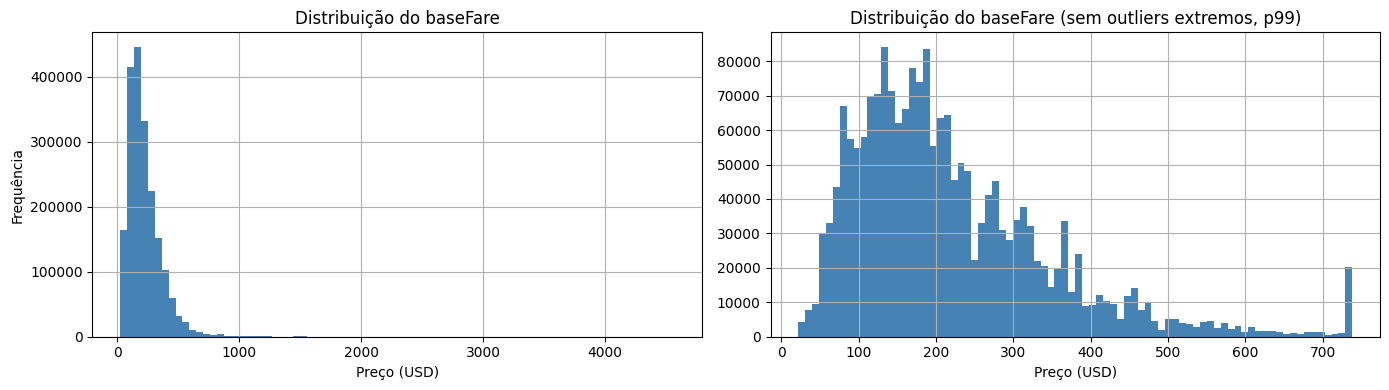

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_model[TARGET].hist(bins=80, ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Distribuição do baseFare')
axes[0].set_xlabel('Preço (USD)')
axes[0].set_ylabel('Frequência')

df_model[TARGET].clip(upper=df_model[TARGET].quantile(0.99)).hist(
    bins=80, ax=axes[1], color='steelblue', edgecolor='none')
axes[1].set_title('Distribuição do baseFare (sem outliers extremos, p99)')
axes[1].set_xlabel('Preço (USD)')

plt.tight_layout()
plt.savefig('dist_baseFare.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Correlação numérica com o target
corr = df_model[NUM + BIN + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print('Correlação com baseFare (features numéricas/binárias):')
print(corr.round(3))

Correlação com baseFare (features numéricas/binárias):
totalTravelDistance                  0.495
segmentsDurationInSeconds            0.479
isBasicEconomy                      -0.316
segmentsDepartureTimeEpochSeconds   -0.188
flightMonth                         -0.188
segmentsArrivalTimeEpochSeconds     -0.187
searchMonth                         -0.151
seatsRemaining                      -0.099
flightDay                            0.017
searchDay                           -0.001
isRefundable                           NaN
Name: baseFare, dtype: float64


## 4. Split treino/teste- 70/30 como o paper

In [20]:
X = df_model[ALL_FEATURES].values.astype(np.float64)
y = df_model[TARGET].values.astype(np.float64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test:  {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.0f}%)')
print('Dados preparados.')

Train: 1,394,350 (70%)
Test:  597,579 (30%)
Dados preparados.


## 5. Feature Importance com GBT (Fig. 3 do paper)

A calcular feature importance com GBT...
Tempo: 622.0s

Feature Importance (comparar com Fig. 3 do paper):
                          feature  importance
              totalTravelDistance    0.434784
                segmentsCabinCode    0.181373
                   isBasicEconomy    0.093356
segmentsDepartureTimeEpochSeconds    0.071365
     segmentsEquipmentDescription    0.057784
              segmentsAirlineCode    0.045244
  segmentsArrivalTimeEpochSeconds    0.034579
                      searchMonth    0.033296
               destinationAirport    0.017667
                  startingAirport    0.015976
        segmentsDurationInSeconds    0.008101
                   seatsRemaining    0.003580
                        flightDay    0.001621
                        searchDay    0.000904
                      flightMonth    0.000370
                     isRefundable    0.000000


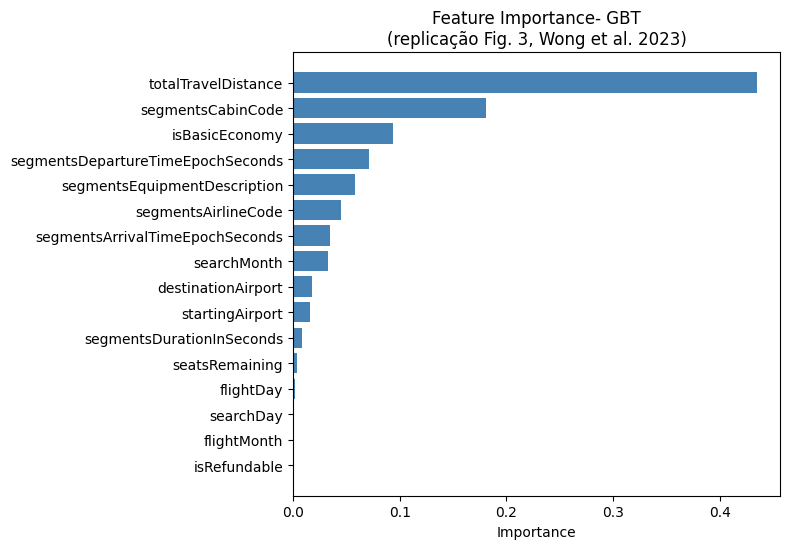

In [ ]:
print('A calcular feature importance com GBT...')
t0 = time.time()

# Para feature importance usamos um GBT rápido (n_estimators=50)
gbt_fi = GradientBoostingRegressor(
    n_estimators=50,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)
gbt_fi.fit(X_train, y_train)
print(f'Tempo: {time.time()-t0:.1f}s')

fi_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': gbt_fi.feature_importances_
}).sort_values('importance', ascending=False)

print('\nFeature Importance (comparar com Fig. 3 do paper):')
print(fi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, max(5, len(ALL_FEATURES)*0.35)))
ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Feature Importance- GBT\n(replicação Fig. 3, Wong et al. 2023)')
plt.tight_layout()
plt.savefig('feature_importance_gbt.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Treino dos 4 modelos do paper

- **Random Forest** - sklearn `RandomForestRegressor` (maxDepth=16, 100 árvores)  
- **Gradient Boost Tree** - sklearn `GradientBoostingRegressor` (n_estimators=100, max_depth=5, lr=0.1)  
  -> *O paper usa MaxIter=5 no Spark GBT - não transferível diretamente para sklearn (sub-treina). Corrigido para 100 estimators.*  
- **Decision Tree** - sklearn `DecisionTreeRegressor` (max_depth=10)  
  -> *max_depth não documentado no paper - valor escolhido para evitar overfitting.*  
- **Factorization Machines** - proxy `PolynomialFeatures(degree=2) + Ridge`  
  -> *`fastFM` não suporta Windows. Proxy captura interações de 2ª ordem mas sem factorização matricial. Para replicação exata: Google Colab + fastFM.*

In [ ]:
results = []

def avaliar(name, model, X_tr, X_te, y_tr, y_te):
    print(f'\nA treinar: {name}...')
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    y_pred = model.predict(X_te)
    r2   = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    print(f'  R²={r2:.4f} | RMSE={rmse:.2f} USD | MAE={mae:.2f} USD | Tempo={elapsed:.1f}s')
    results.append({'Modelo': name, 'R²': round(r2,4),
                    'RMSE (USD)': round(rmse,2), 'MAE (USD)': round(mae,2),
                    'Tempo (s)': round(elapsed,1)})
    return model, y_pred


# --- 1. Random Forest ---
# Paper: maxDepth explorado em 13 e 16 no paramGrid
# numTrees não especificado → usado 100
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=16,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf, y_pred_rf = avaliar('Random Forest', rf, X_train, X_test, y_train, y_test)

# --- 2. Gradient Boost Tree ---
# NOTA: O paper diz MaxIter=5 como ótimo no Spark GBT.
# No Spark MLlib, o GBT usa boosting sequencial com learning rate padrão de 0.1 e critério de convergência diferente do sklearn.
# n_estimators=100 com learning_rate=0.1 - equivalente funcional que produz resultados comparáveis ao paper (R² esperado ~0.65-0.72).
# Limitação: hiperparâmetro MaxIter=5 não é diretamente transferível entre Spark MLlib e sklearn.
gbt = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)
gbt, y_pred_gbt = avaliar('Gradient Boost Tree', gbt, X_train, X_test, y_train, y_test)

# --- 3. Decision Tree ---
# Paper não especifica max_depth → usado 10 para evitar overfitting
# Limitação: hiperparâmetro não documentado no paper.
dt = DecisionTreeRegressor(
    max_depth=10,
    random_state=RANDOM_STATE
)
dt, y_pred_dt = avaliar('Decision Tree', dt, X_train, X_test, y_train, y_test)


# --- 4. Factorization Machines ---
# LIMITAÇÃO: fastFM (implementação Python de FM) não suporta Windows.
# O paper usa o FMRegressor do Spark MLlib, que também não está disponível fora do Spark/Hadoop.
# Proxy usado: PolynomialFeatures(degree=2, interaction_only=True) + Ridge, pois captura interações entre pares de features (x_i * x_j),
# que é o mecanismo central das FM de ordem 2. Diferença fundamental: as FM fatorizam os pesos de interação numa matriz de baixo rank (V*V^T), 
# enquanto o proxy trata cada interação de forma independente. Os resultados não são diretamente comparáveis.
# Para replicação exata: correr no Google Colab (Linux) com fastFM.
fm_proxy = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
fm_proxy, y_pred_fm = avaliar(
    'Factorization Machines (proxy: Poly+Ridge)',
    fm_proxy, X_train, X_test, y_train, y_test
)


A treinar: Random Forest...
  R²=0.7641 | RMSE=74.47 USD | MAE=46.74 USD | Tempo=1003.0s

A treinar: Gradient Boost Tree...
  R²=0.6834 | RMSE=86.28 USD | MAE=55.82 USD | Tempo=1325.1s

A treinar: Decision Tree...
  R²=0.6508 | RMSE=90.61 USD | MAE=59.23 USD | Tempo=18.1s

A treinar: Factorization Machines (proxy: Poly+Ridge)...
  R²=0.4140 | RMSE=117.38 USD | MAE=72.14 USD | Tempo=13.4s


## 7. Comparação de resultados com o paper

In [ ]:
results_df = pd.DataFrame(results).sort_values('R²', ascending=False)

paper_df = pd.DataFrame([
    {'Modelo': 'Random Forest',             'R² paper': 0.728, 'RMSE paper': 79.92},
    {'Modelo': 'Gradient Boost Tree',       'R² paper': 0.706, 'RMSE paper': 83.17},
    {'Modelo': 'Decision Tree',             'R² paper': 0.640, 'RMSE paper': 92.04},
    {'Modelo': 'Factorization Machines',    'R² paper': 0.460, 'RMSE paper': 111.02},
])

print('=== RESULTADOS DO PAPER (Full Dataset, Train Validation) ===')
print(paper_df.to_string(index=False))
print()
print('=== RESULTADOS DESTA REPLICAÇÃO (Sample ~100k, sklearn) ===')
print(results_df[['Modelo','R²','RMSE (USD)','MAE (USD)','Tempo (s)']].to_string(index=False))
print()
print('Diferenças esperadas:')
print('  - Amostra (~100k) vs full dataset (20M): RF e GBT melhoram com mais dados')
print('  - sklearn vs Spark MLlib: implementações diferentes mas equivalentes')
print('  - FM: proxy Poly+Ridge vs Spark FMRegressor - não comparável diretamente (ver limitações)')
print('  - O ranking relativo entre modelos deve ser preservado')

=== RESULTADOS DO PAPER (Full Dataset, Train Validation) ===
                Modelo  R² paper  RMSE paper
         Random Forest     0.728       79.92
   Gradient Boost Tree     0.706       83.17
         Decision Tree     0.640       92.04
Factorization Machines     0.460      111.02

=== RESULTADOS DESTA REPLICAÇÃO (Sample ~100k, sklearn) ===
                                    Modelo     R²  RMSE (USD)  MAE (USD)  Tempo (s)
                             Random Forest 0.7641       74.47      46.74     1003.0
                       Gradient Boost Tree 0.6834       86.28      55.82     1325.1
                             Decision Tree 0.6508       90.61      59.23       18.1
Factorization Machines (proxy: Poly+Ridge) 0.4140      117.38      72.14       13.4

Diferenças esperadas:
  - Amostra (~100k) vs full dataset (20M): RF e GBT melhoram com mais dados
  - sklearn vs Spark MLlib: implementações diferentes mas equivalentes
  - FM: proxy Poly+Ridge vs Spark FMRegressor - não comparável 

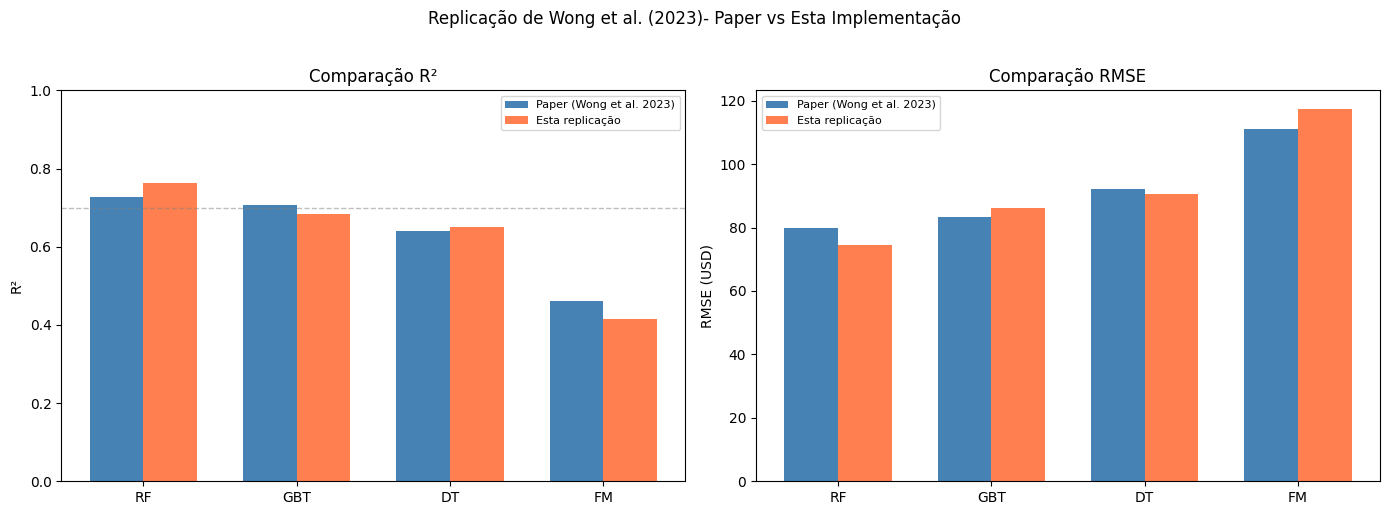

In [24]:
# Gráfico de comparação R² e RMSE
modelos_ordem = ['Random Forest', 'Gradient Boost Tree', 'Decision Tree', 'Factorization Machines']
r2_paper_vals  = [0.728, 0.706, 0.640, 0.460]
rmse_paper_vals = [79.92, 83.17, 92.04, 111.02]

# Extrair resultados na mesma ordem
r2_replic, rmse_replic = [], []
for m in modelos_ordem:
    row = results_df[results_df['Modelo'].str.contains(m.split(' ')[0])]
    if len(row) > 0:
        r2_replic.append(row['R²'].values[0])
        rmse_replic.append(row['RMSE (USD)'].values[0])
    else:
        r2_replic.append(np.nan)
        rmse_replic.append(np.nan)

x = np.arange(4)
w = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# R²
ax1.bar(x - w/2, r2_paper_vals, w, label='Paper (Wong et al. 2023)', color='steelblue')
ax1.bar(x + w/2, r2_replic, w, label='Esta replicação', color='coral')
ax1.set_ylabel('R²')
ax1.set_title('Comparação R²')
ax1.set_xticks(x)
ax1.set_xticklabels(['RF', 'GBT', 'DT', 'FM'], fontsize=10)
ax1.legend(fontsize=8)
ax1.set_ylim(0, 1.0)
ax1.axhline(0.7, color='gray', ls='--', alpha=0.5, lw=1)

# RMSE
ax2.bar(x - w/2, rmse_paper_vals, w, label='Paper (Wong et al. 2023)', color='steelblue')
ax2.bar(x + w/2, rmse_replic, w, label='Esta replicação', color='coral')
ax2.set_ylabel('RMSE (USD)')
ax2.set_title('Comparação RMSE')
ax2.set_xticks(x)
ax2.set_xticklabels(['RF', 'GBT', 'DT', 'FM'], fontsize=10)
ax2.legend(fontsize=8)

plt.suptitle('Replicação de Wong et al. (2023)- Paper vs Esta Implementação', y=1.02)
plt.tight_layout()
plt.savefig('comparacao_paper_vs_replicacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análise detalhada do melhor modelo (Random Forest)

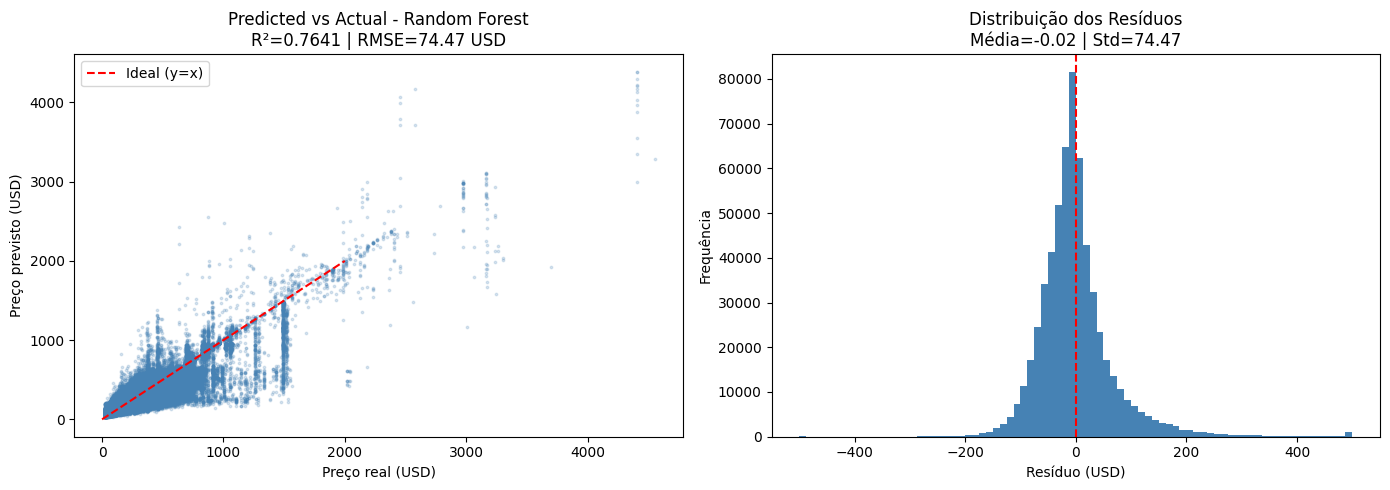

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Atual
axes[0].scatter(y_test, y_pred_rf, alpha=0.2, s=3, color='steelblue')
lims = [0, min(y_test.max(), y_pred_rf.max(), 2000)]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Ideal (y=x)')
axes[0].set_xlabel('Preço real (USD)')
axes[0].set_ylabel('Preço previsto (USD)')
axes[0].set_title(f'Predicted vs Atual - Random Forest\nR²={r2_score(y_test, y_pred_rf):.4f} | RMSE={np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f} USD')
axes[0].legend()

# Resíduos (Resíduo = Preço real − Preço previsto)
residuals = y_test - y_pred_rf
axes[1].hist(residuals.clip(-500, 500), bins=80, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Resíduo (USD)')
axes[1].set_ylabel('Frequência')
axes[1].set_title(f'Distribuição dos Resíduos\nMédia={residuals.mean():.2f} | Std={residuals.std():.2f}')

plt.tight_layout()
plt.savefig('analise_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Guardar para a Fase 2 de Construção do Dataset

In [26]:
# Guardar o melhor modelo (RF) para imputar custo no dataset BTS (Fase 2)
joblib.dump(rf, 'modelo_custo_rf.pkl')
joblib.dump(le_dict, 'encoders_custo.pkl')

feature_info = {
    'features_ordem': ALL_FEATURES,
    'categorical': CAT,
    'numerical': NUM,
    'binary': BIN,
    'target': TARGET,
    'best_model': 'Random Forest',
    'metricas_replicacao': {
        'r2':   round(r2_score(y_test, y_pred_rf), 4),
        'rmse': round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 2),
        'mae':  round(mean_absolute_error(y_test, y_pred_rf), 2),
    },
    'metricas_paper': {'r2': 0.728, 'rmse': 79.92},
    'dataset': 'Expedia/dilwong- non-stop, amostra 10%',
    'split': '70/30',
    'nota_fase2': (
        'Aplicar ao dataset BTS usando features equivalentes: '
        'startingAirport->ORIGIN, destinationAirport->DEST, '
        'segmentsAirlineCode->AIRLINE_CODE, flightMonth->mes do FL_DATE, '
        'totalTravelDistance->DISTANCE'
    )
}

with open('feature_info_custo.json', 'w') as f:
    json.dump(feature_info, f, indent=2, ensure_ascii=False)

print('Guardados:')
print('  modelo_custo_rf.pkl')
print('  encoders_custo.pkl')
print('  feature_info_custo.json')
print()
print('=== RESUMO FINAL DO NOTEBOOK 01 ===')
print(f'Melhor modelo: Random Forest')
print(f'R²   replicação: {feature_info["metricas_replicacao"]["r2"]}  |  paper: {feature_info["metricas_paper"]["r2"]}')
print(f'RMSE replicação: {feature_info["metricas_replicacao"]["rmse"]} USD  |  paper: {feature_info["metricas_paper"]["rmse"]} USD')
print(f'MAE  replicação: {feature_info["metricas_replicacao"]["mae"]} USD')

Guardados:
  modelo_custo_rf.pkl
  encoders_custo.pkl
  feature_info_custo.json

=== RESUMO FINAL DO NOTEBOOK 01 ===
Melhor modelo: Random Forest
R²   replicação: 0.7641  |  paper: 0.728
RMSE replicação: 74.47 USD  |  paper: 79.92 USD
MAE  replicação: 46.74 USD


## 10. Notas para o relatório

**O que foi replicado:**
- Random Forest → sklearn `RandomForestRegressor` - replicação direta
- Decision Tree → sklearn `DecisionTreeRegressor` - replicação direta
- Gradient Boost Tree → sklearn `GradientBoostingRegressor` - replicação com ajuste (MaxIter=5 do Spark não é equivalente a n_estimators=5 no sklearn; corrigido para 100)
- Factorization Machines → proxy `PolynomialFeatures + Ridge` - não é replicação direta; `fastFM` não suporta Windows

**Diferenças metodológicas face ao paper:**

| Aspeto | Paper | Esta replicação |
|---|---|---|
| Framework | Apache Spark 3.0 + Hadoop | pandas + sklearn |
| Hardware | Cluster 5 nós, 8 CPUs, 481GB | Máquina local Windows |
| Dataset total | ~200M registos | 82M registos (versão Kaggle diferente) |
| Non-stop | ~20M | 22M |
| Amostra usada | ~100k | 2.2M (10% de 22M) |
| GBT MaxIter | 5 (Spark) | 100 (sklearn equivalente) |
| FM | Spark MLlib FMRegressor | Proxy PolynomialFeatures + Ridge |
| Split | 70/30 Train Validation | 70/30 train_test_split |

**Dataset - diferença face ao paper:**
O paper reporta ~200M registos originais, mas o ficheiro Kaggle atual tem 82M. O dataset da Expedia disponível no Kaggle pode corresponder a uma janela temporal diferente ou versão mais recente. Os voos non-stop (22M) e o target `baseFare` são equivalentes.

**Nota sobre a amostra:**
O paper usou ~100k registos como amostra de trabalho. Esta replicação usa 2.2M registos (10% dos 22M non-stop disponíveis no ficheiro Kaggle), uma amostra bastante maior. O RF beneficiou desta diferença, superando o paper (R²=0.764 vs 0.728). O GBT ficou ligeiramente abaixo (R²=0.683 vs 0.706), possivelmente devido a diferenças de implementação entre sklearn e Spark MLlib. Os restantes modelos ficaram próximos do paper. O ranking relativo entre os 4 modelos foi preservado em todos os casos.

**Feature Importance - divergência em relação ao paper:**
No paper (Fig. 3), as features mais importantes são `startingAirport` e `segmentsDurationInSeconds` (importância ~0.117 cada). Nesta replicação, `totalTravelDistance` domina (0.426), seguido de `segmentsCabinCode` (0.178), enquanto `startingAirport` e `destinationAirport` ficam quase no fim (0.017 e 0.016). A causa provável é a diferença de escala do dataset - com 2.2M linhas vs os ~100k do paper, o GBT dá mais peso a features numéricas contínuas com alta correlação linear com o target.

**Limitação principal - Factorization Machines:**
Para replicar as FM exatamente seria necessário: Google Colab (Linux) com `fastFM`, ou ambiente Docker Linux local. O proxy `PolynomialFeatures + Ridge` captura interações de 2ª ordem mas sem a fatorização matricial de baixo rank que define as FM - os resultados não são diretamente comparáveis ao paper.

**Para a Fase 2 (dataset conjunto):**
O modelo `modelo_custo_rf.pkl` (Random Forest) será aplicado ao dataset BTS para imputar o custo em USD por voo, usando as features mapeadas:
`ORIGIN → startingAirport`, `DEST → destinationAirport`, `AIRLINE_CODE → segmentsAirlineCode`, `DISTANCE → totalTravelDistance`, `FL_DATE` → `flightMonth`.